In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize, least_squares
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from tqdm import tqdm
from adjustText import adjust_text

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'DejaVu Sans'
#rcParams['font.family'] = 'sans-serif'
#rcParams['font.sans-serif'] = ['Arial']

pd.set_option("display.max_colwidth", None)

In [12]:
# Parameters
fc_thresh = 1
p_thresh = 0.05

In [13]:
# Paths
out_dir = Path("../../out/D39/diff_expr/")
out_dir_V = Path("../../out/D39V/diff_expr/")
data_dir = Path("../../data/reference/D39/")
data_dir_V = Path("../../data/reference/D39V/")
contrast_file = out_dir / "contrast_table.tsv"
contrast_file_V = out_dir_V / "contrast_table.tsv"
gff = data_dir / "D39.gff"
gff_V = data_dir_V / "D39V.gff3"

In [14]:
# Load data
contrasts = pd.read_csv(contrast_file, sep="\t")
ref = pd.read_csv(gff, sep="\t", comment="#", header=None,
                     names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])
contrasts_V = pd.read_csv(contrast_file_V, sep="\t")
ref_V = pd.read_csv(gff_V, sep="\t", comment="#", header=None,
                     names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])

In [15]:
# Filter for genes or CDS
genes = ref_V[ref_V["type"].isin(["gene", "CDS"])]

# Function to extract attributes
def parse_attributes(attr_str):
    attrs = {}
    for item in attr_str.split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            attrs[k] = v

    return pd.Series({
        "locus_tag": attrs.get("locus_tag", ""),
        "gene_id": attrs.get("gene", attrs.get("ID", "")),
        "gene_name": attrs.get("Name", attrs.get("gene", "")),
        "product": attrs.get("product", "")
    })

# Apply parsing
gene_attr = genes["attributes"].apply(parse_attributes)

# Combine with positional info
gene_df_V = pd.concat([genes[["seqid", "start", "end", "strand"]], gene_attr], axis=1)

In [16]:
gene_df_V["locus_tag"].nunique()

2099

In [17]:
gene_df_V["gene_id"].nunique()

2897

In [34]:
gene_df_V[gene_df_V["gene_id"] == "mtlR"]

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1923,CP027540.1,363539,365494,+,SPV_0361,mtlR,mtlR,
1924,CP027540.1,363539,365494,+,SPV_0361,mtlR,AVN85524.1,Mannitol operon activator%2C BglG family


In [18]:
# Filter for genes or CDS
genes = ref[ref["type"].isin(["gene", "CDS"])]

# Function to extract attributes
def parse_attributes(attr_str):
    attrs = dict(item.split("=") for item in attr_str.split(";") if "=" in item)
    return pd.Series({
        "locus_tag": attrs.get("locus_tag", ""),
        "gene_id": attrs.get("gene", ""),
        "gene_name": attrs.get("gene_name", ""),
        "product": attrs.get("product", "")
    })

# Apply parsing
gene_attr = genes["attributes"].apply(parse_attributes)

# Combine with positional info
gene_df = pd.concat([genes[["seqid", "start", "end", "strand"]], gene_attr], axis=1)

In [19]:
gene_df["locus_tag"].nunique()

2098

In [20]:
gene_df["gene_id"].nunique()

613

In [21]:
gene_df.to_csv("../../out/D39/diff_expr/gene_df.tsv", sep="\t", index=None)
gene_df_V.to_csv("../../out/D39V/diff_expr/gene_df.tsv", sep="\t", index=None)

In [30]:
def volcano_plot(df, gff_df=None, title="", fc_thresh=1, p_thresh=0.05, save_path=None):
    # Detect fold change column
    fc_cols = [c for c in df.columns if 'log2' in c.lower() and 'fold' in c.lower()]
    if not fc_cols:
        raise ValueError("No log2 fold change column found")
    fc_col = fc_cols[0]

    # Detect adjusted p-value column
    padj_cols = [c for c in df.columns if 'padj' in c.lower()]
    if not padj_cols:
        raise ValueError("No adjusted p-value column found")
    padj_col = padj_cols[0]

    # Detect gene/feature column
    gene_cols = [c for c in df.columns if c.lower() in ['gene','feature_id','id']]
    gene_col = gene_cols[0] if gene_cols else 'gene'
    df['gene'] = df[gene_col]

    # Replace zeros and compute -log10(padj)
    df[padj_col] = df[padj_col].replace(0, 1e-300)
    df['-log10(padj)'] = -np.log10(df[padj_col])

    
    # Create a column for display labels from GFF
    # this would normally keep all labels (locus tag and gene)
    if gff_df is not None:
        # Map: prefer gene_name > gene_id > locus_tag
        label_map = {}
        for _, row in gff_df.iterrows():
            label_map[row['locus_tag']] = row['gene_id'] if row['gene_id'] else (
                                          row['gene_name'] if row['gene_name'] else row['locus_tag'])
        df['label'] = df['gene'].map(label_map).fillna(df['gene'])
    else:
        df['label'] = df['gene'] if 'gene' in df.columns else df.index.astype(str)

    # Assign colors
    df['color'] = np.where(
        (df[padj_col] < p_thresh) & (df[fc_col] > fc_thresh), 'red',
        np.where((df[padj_col] < p_thresh) & (df[fc_col] < -fc_thresh), 'green', 'grey')
    )

    # same alike above, this would keep all labels
    # Top labels to annotate
    keep_labels = df.loc[
        (df[padj_col] < p_thresh) & 
        ((abs(df[fc_col]) > df[fc_col].abs().max()*0.5) | 
         (df['-log10(padj)'] > df['-log10(padj)'].max()*0.9)),
        'label'
    ].tolist()

    plt.figure(figsize=(8,7))
    plt.scatter(df[fc_col], df['-log10(padj)'], c=df['color'], alpha=0.5, edgecolors='none', zorder=1)

    plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--', zorder=2)
    plt.axvline(fc_thresh, color='grey', linestyle='--', zorder=2)
    plt.axvline(-fc_thresh, color='grey', linestyle='--', zorder=2)

    # Annotate
    texts = []
    for gene in keep_labels:
        g_row = df[df['label'] == gene].iloc[0]
        texts.append(plt.text(g_row[fc_col], g_row['-log10(padj)'], gene, fontsize=12))

    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='black', lw=0.25),
                expand_points=(1.2, 1.2),
                force_points=0.2)

    y_min = df['-log10(padj)'].min()
    xlim = max(abs(df[fc_col].max()), abs(df[fc_col].min()))
    plt.xlim(-xlim*1.05, xlim*1.05)
    plt.ylim(-30, df['-log10(padj)'].max()*1.05)

    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted Pvalue")
    plt.title(title, fontsize=16)
    plt.gca().set_facecolor("white")

    if save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
    plt.show()

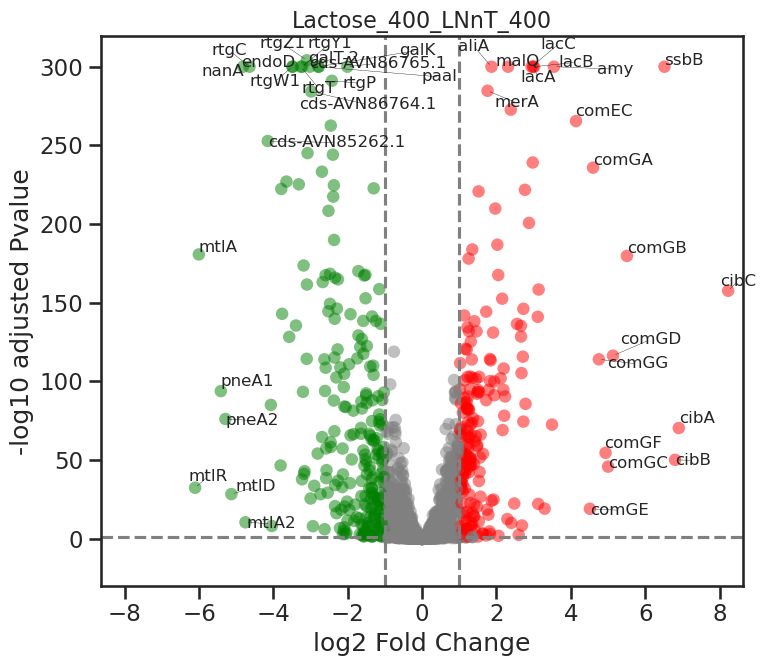

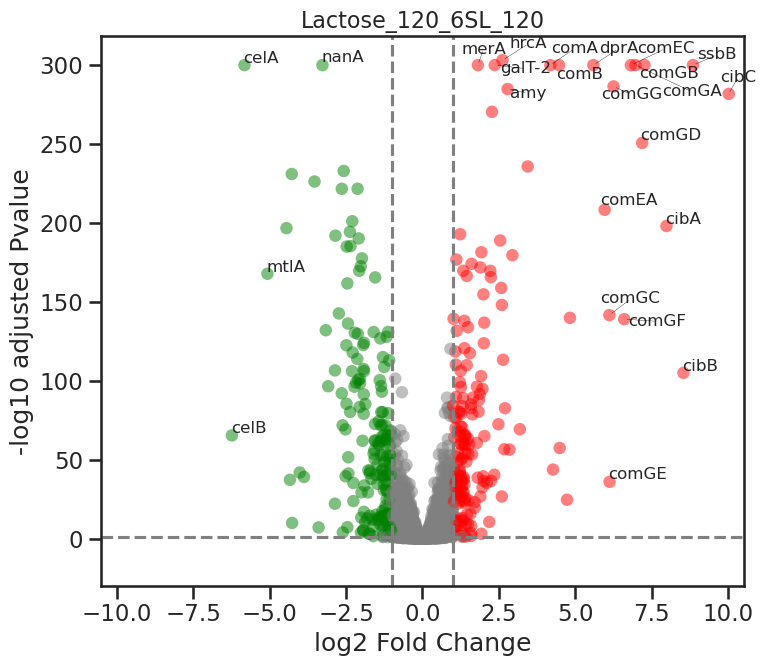

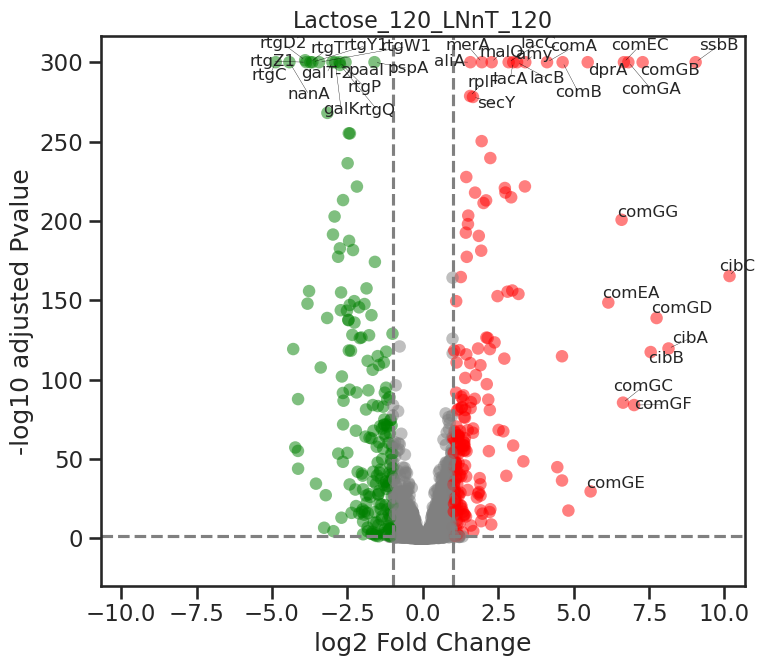

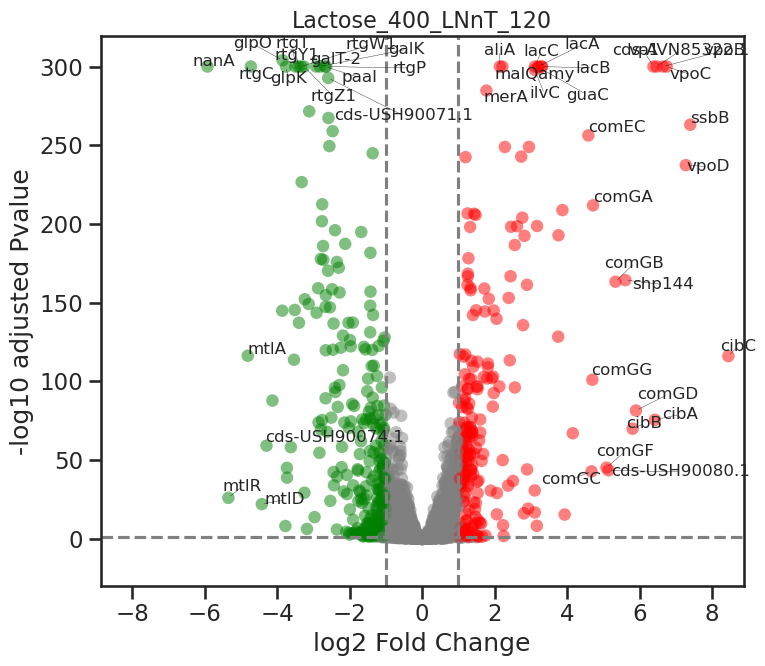

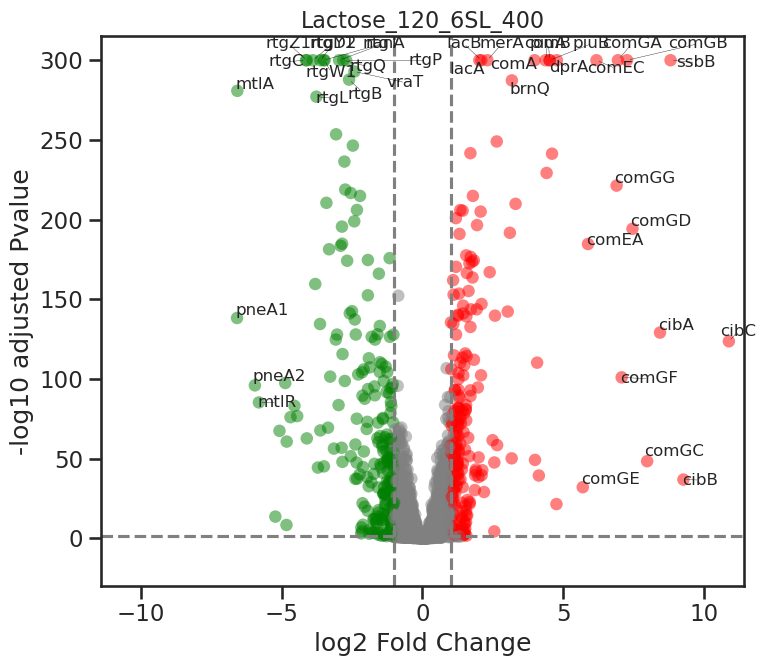

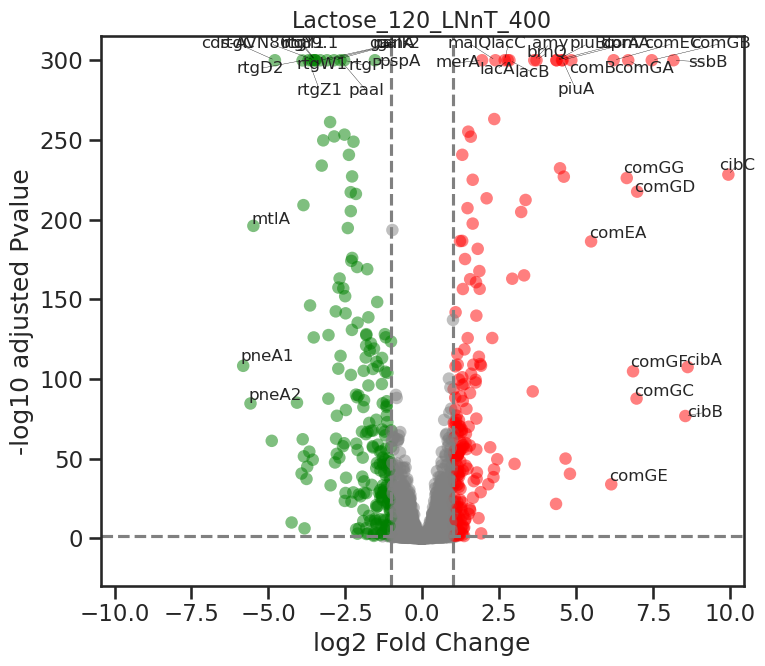

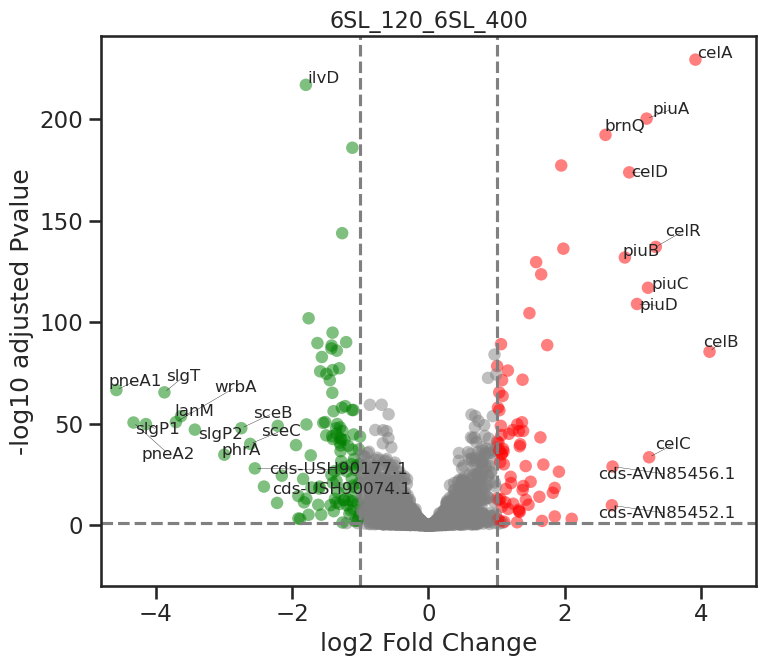

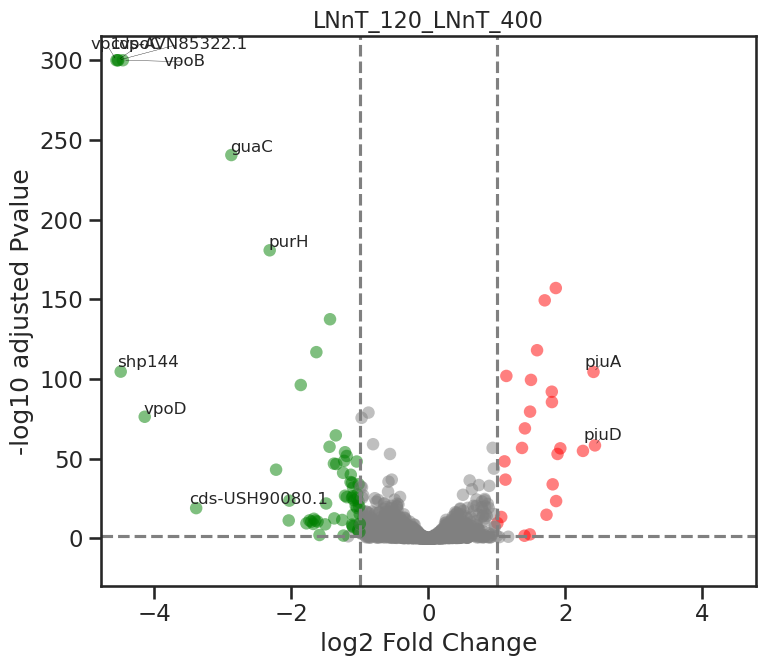

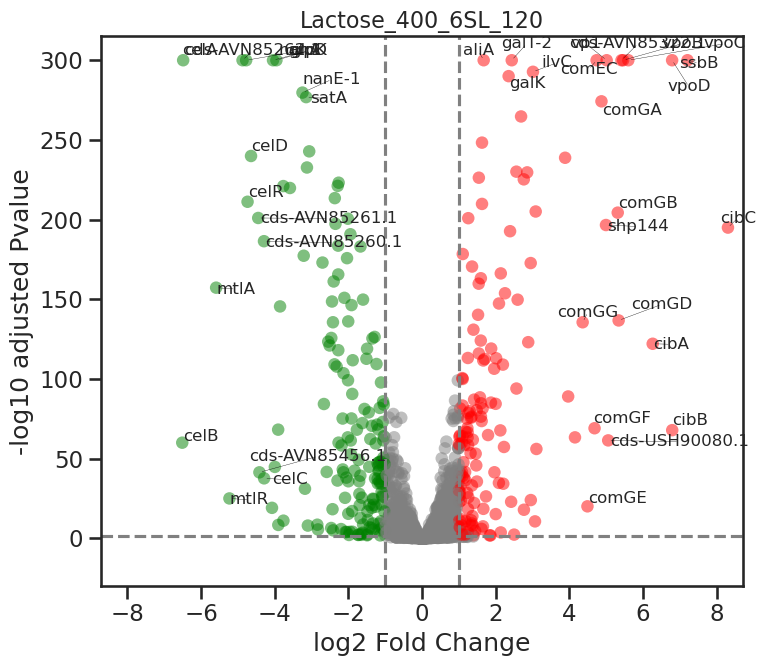

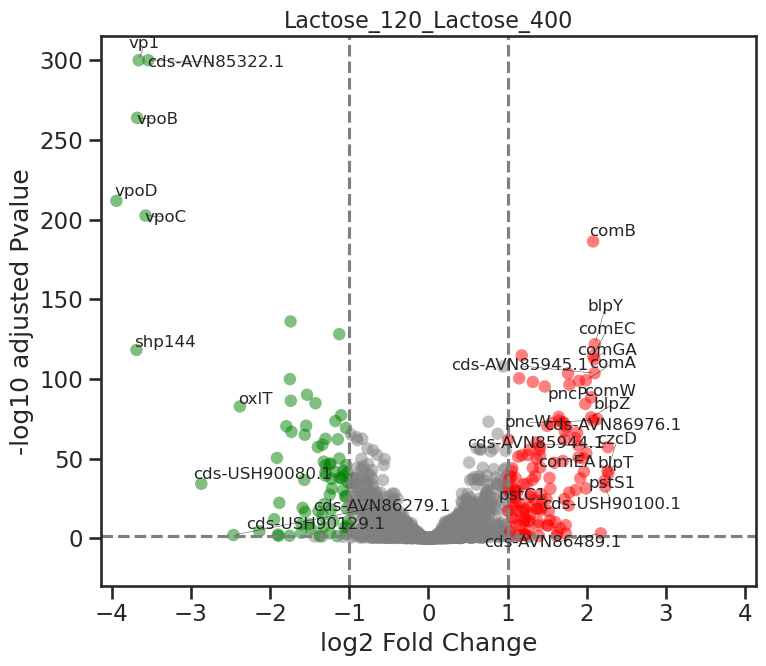

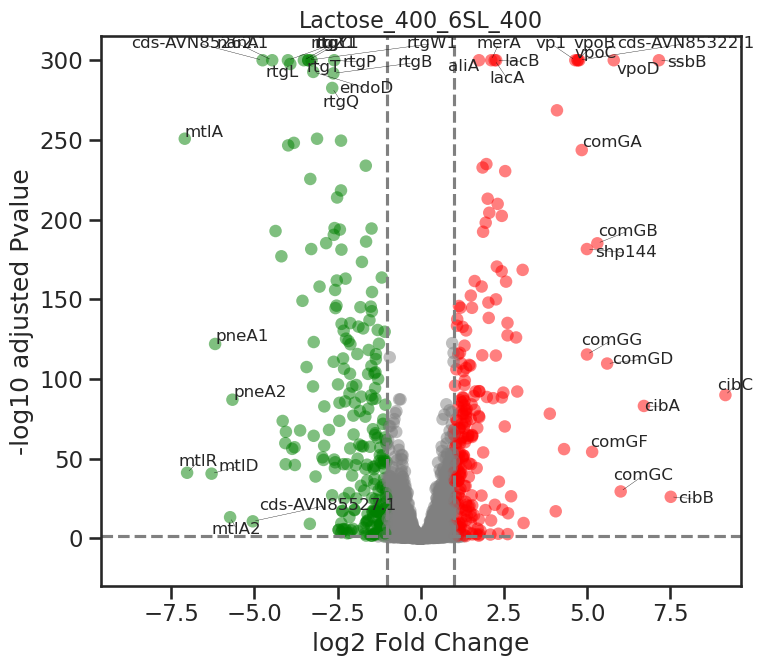

In [31]:
# Loop through DGE files
for file in out_dir_V.glob("DGE_*.tsv"):
    df = pd.read_csv(file, sep="\t")
    contrast_name = file.stem.replace("DGE_", "")
    volcano_plot(df, title=contrast_name, gff_df=gene_df_V,
                 fc_thresh=fc_thresh, p_thresh=p_thresh,
                 save_path=out_dir_V / f"annotated_volcano_plot_{contrast_name}.png")

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


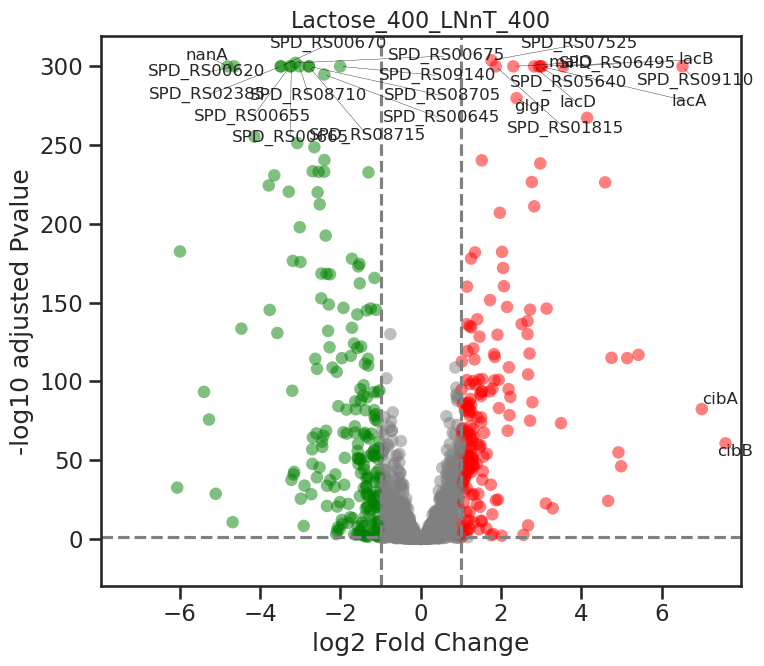

6 [ 0.96557074 -0.80160654]
13 [-0.44807899 -0.79854745]
6 [-0.07816276 -0.71018156]
13 [0.16598838 0.74471937]
6 [0.94242031 0.70923508]
13 [-0.53670944  0.11405161]
6 [-0.92116798  0.2768802 ]
13 [-0.54074537 -0.42416273]
6 [-0.14219588  0.80006604]
13 [ 0.27039478 -0.6929666 ]
6 [-0.22149557  0.14614208]
13 [0.23201349 0.53960629]
6 [-0.59898179  0.58623259]
13 [-0.6894255   0.40261907]
6 [-0.8557773   0.65028036]
13 [0.54103204 0.14355943]
6 [0.1874162  0.44548175]
13 [0.0814199 0.4898519]
6 [-0.71208022  0.06377951]
13 [-0.31769944  0.99951027]
6 [-0.0068701   0.93493938]
13 [-0.06959213  0.29980557]
6 [-0.41909371  0.93449374]
13 [0.03055837 0.70873677]
6 [ 0.30286389 -0.8688231 ]
13 [-0.33993558  0.37111469]
6 [-0.68534704  0.11649673]
13 [0.51181837 0.52164752]
6 [0.69388779 0.82253061]
13 [-0.42595994  0.88000339]
6 [-0.51937353 -0.26961871]
13 [ 0.22688503 -0.1805427 ]
6 [ 0.15007483 -0.55140451]
13 [-0.50149221 -0.69537829]
6 [0.91539019 0.24541427]
13 [ 0.11240179 -0.640343

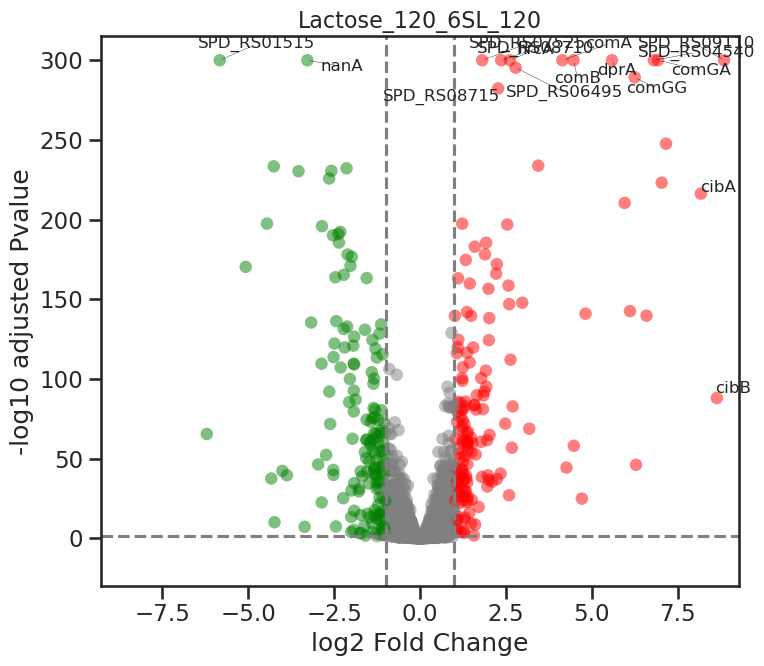

9 [ 0.05817967 -0.03883565]
25 [0.58436809 0.87437728]
6 [-0.60773664  0.83395463]
25 [0.49305828 0.22280918]
6 [0.95809108 0.15545854]
25 [ 0.88570218 -0.16564059]
6 [-0.81895045  0.26983052]
25 [0.61364703 0.06070983]
6 [-0.76436963 -0.70632249]
25 [0.55316902 0.32585514]
6 [-0.4218424  0.3768454]
25 [0.42712136 0.42368965]
6 [-0.9898343  -0.32869219]
25 [0.27037382 0.42835042]
6 [-0.42504597 -0.50774336]
7 [8.49294059e-01 4.85697699e-04]
25 [-0.89363854 -0.0608005 ]
6 [0.96709918 0.30890079]
25 [-0.68739593  0.06640295]
6 [-0.17261549 -0.12921492]
7 [0.75520718 0.60648522]
7 [-0.94146281 -0.56921588]
25 [0.78302556 0.02646384]
7 [0.97967078 0.57338288]
25 [-0.74263801  0.15762878]
6 [ 0.98458842 -0.93124061]
7 [ 0.23731827 -0.68569717]
6 [-0.02677645 -0.05852855]
25 [0.19177578 0.36643605]
7 [0.47390729 0.8942173 ]
25 [-0.75039407  0.56653633]
6 [ 0.94286029 -0.57767253]
7 [ 0.83726522 -0.24546369]
7 [-0.82950309  0.01656726]
25 [0.49917401 0.89248538]
7 [-0.15546864 -0.8985527 ]
25

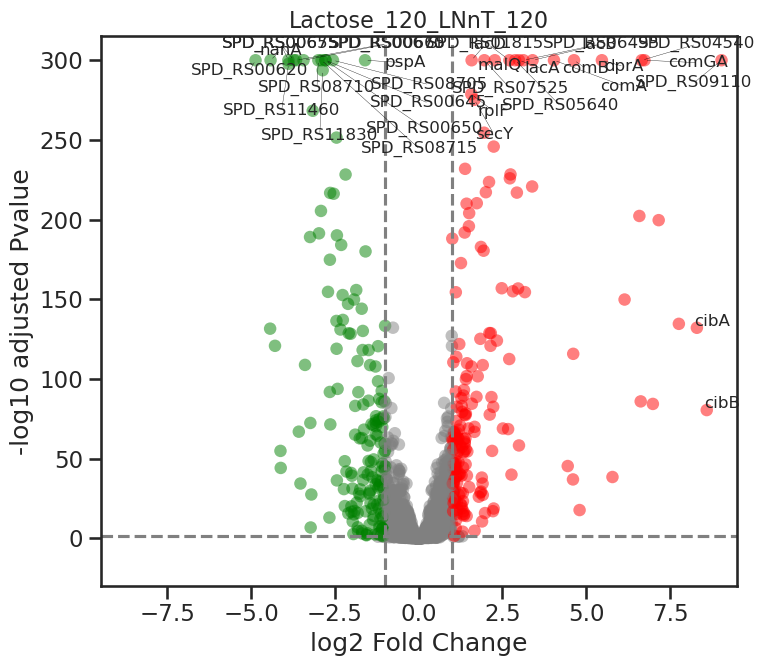

7 [ 0.80734478 -0.86287515]
8 [-0.48738307 -0.49409071]
9 [0.24213929 0.91127584]
10 [-0.20854728 -0.3273759 ]


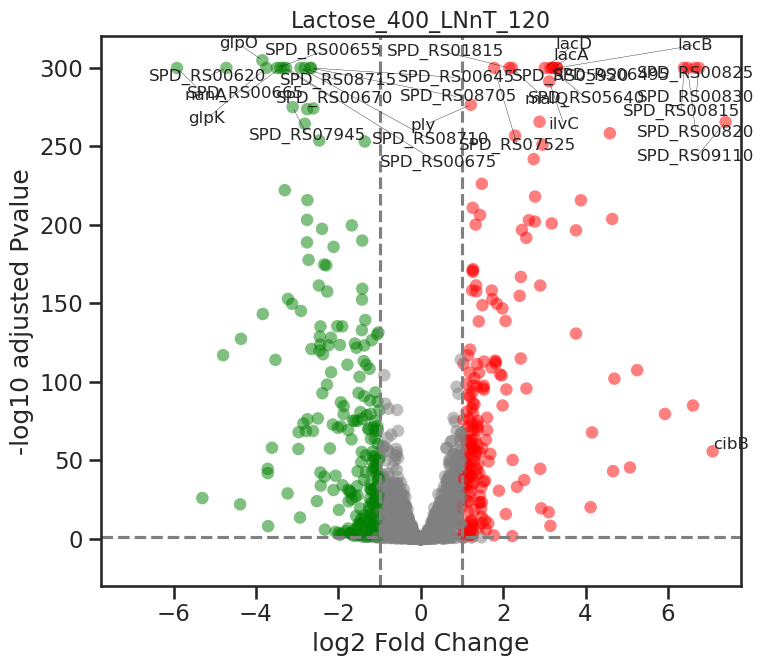

3 [-0.3527375  0.3191661]
11 [-0.07794026  0.04860622]
3 [-0.62334818 -0.1229378 ]
11 [-0.61353496 -0.32879445]


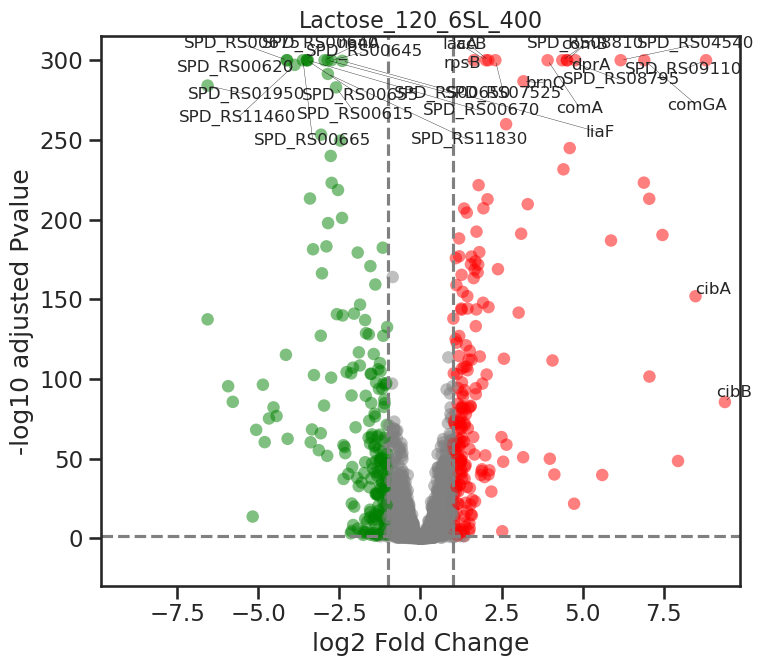

2 [-0.78850529 -0.15122554]
7 [0.80611672 0.38645991]
2 [0.32769246 0.65605731]
7 [-0.50354607  0.6888654 ]
2 [-0.39292387 -0.17119712]
7 [0.21963807 0.68677167]
6 [ 0.21703637 -0.21809451]
7 [-0.59648599 -0.36622025]
6 [0.74554419 0.57456308]
7 [0.60612868 0.55026508]
6 [0.91349822 0.22987223]
7 [0.55359346 0.91388455]
6 [ 0.5003449  -0.25941176]
7 [-0.85879853  0.1117323 ]
6 [-0.39531167 -0.28869731]
7 [ 0.71076666 -0.96191478]
6 [-0.44814002 -0.80562183]
7 [-0.72179831  0.39306069]
6 [ 0.64889828 -0.260335  ]
7 [-0.44290465 -0.4732837 ]
6 [0.91059845 0.81848699]
7 [0.98912877 0.4819398 ]
6 [-0.03159682 -0.72231683]
7 [-0.57059209  0.27263946]
6 [-0.53913272  0.45890562]
7 [-0.43063849 -0.93346756]
6 [0.67600527 0.47837415]
7 [ 0.38573328 -0.4310951 ]
6 [0.32025247 0.41301586]
7 [0.80140415 0.58210262]
6 [0.50080627 0.70548834]
7 [-0.0744161  -0.73163294]
6 [-0.4855064  -0.60052762]
7 [ 0.85475035 -0.46299102]
6 [ 0.27677968 -0.14186507]
7 [-0.02574524 -0.29544079]
6 [-0.13667156  0.

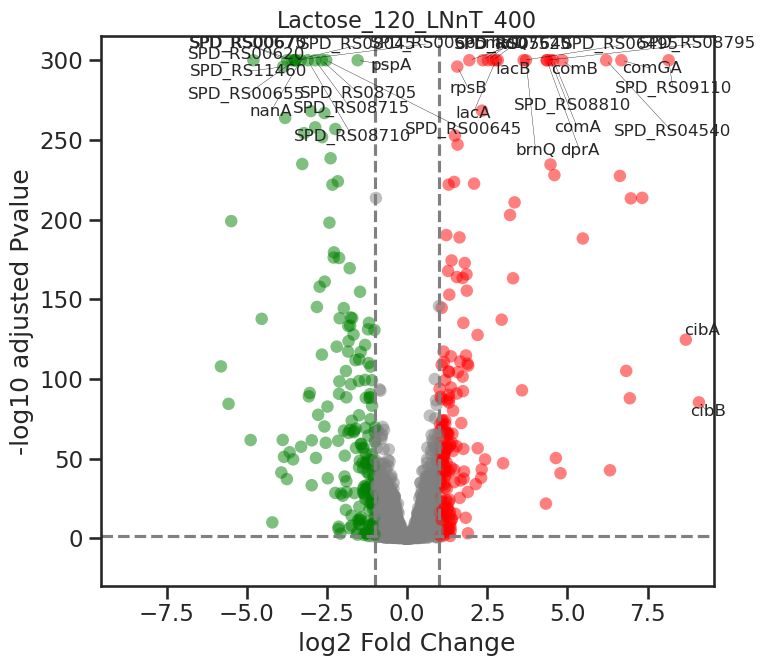

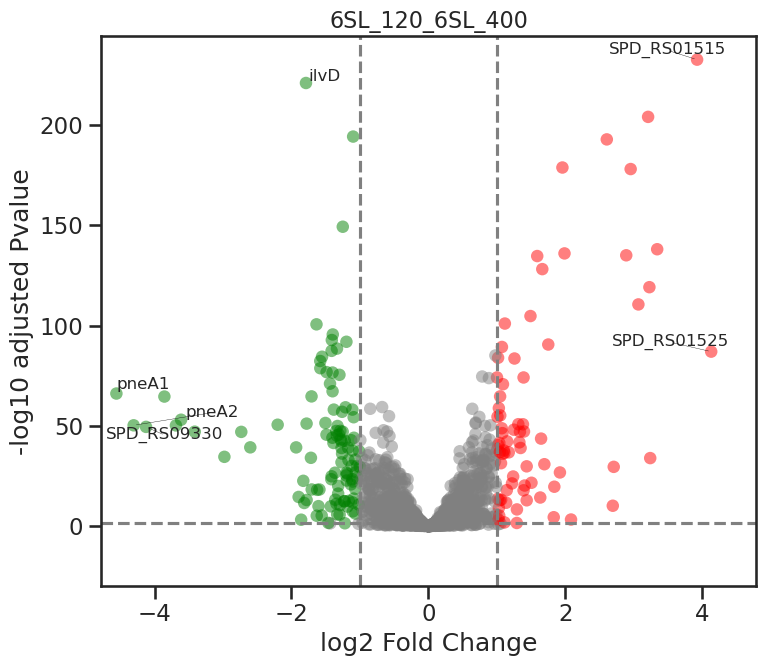

0 [0.6462332  0.11075517]
3 [-0.1292283   0.73850548]


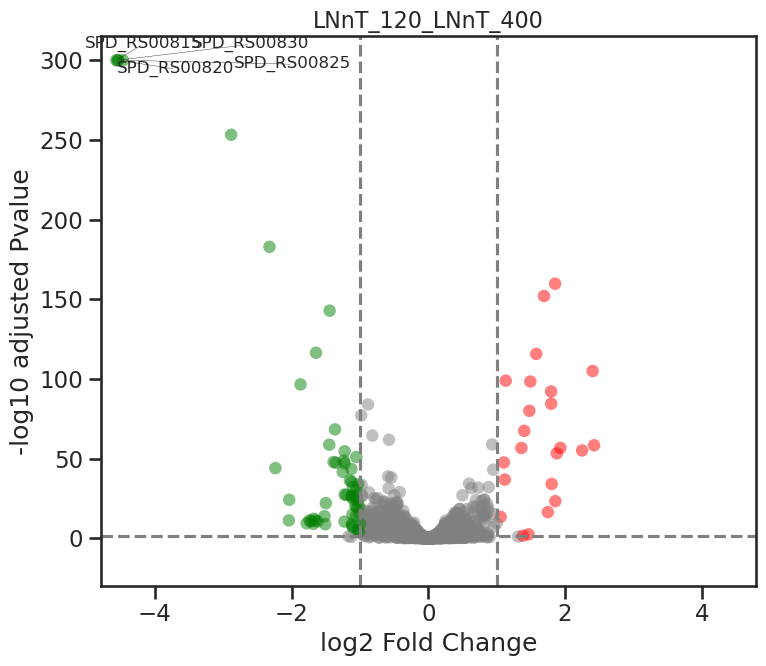

2 [-0.78396733  0.53944382]
10 [0.78761973 0.33042765]
4 [-0.14849118 -0.53600801]
5 [ 0.26908837 -0.61508609]
2 [0.40615786 0.3951476 ]
3 [0.47414527 0.5570021 ]
4 [-0.25140521 -0.82698459]
2 [-0.31759043  0.47239943]
3 [-0.19467755 -0.41707356]
2 [0.73883628 0.59594741]
3 [-0.34069092  0.8223689 ]
10 [-0.28995833  0.76367387]
2 [-0.27098345  0.6653628 ]
3 [0.59943179 0.43653106]
4 [ 0.72138566 -0.01289162]
10 [-0.15101518  0.20586533]
2 [ 0.69578525 -0.41544062]
3 [-0.40144723  0.0947508 ]
4 [-0.52803268 -0.43950929]
10 [ 0.18319521 -0.0536783 ]


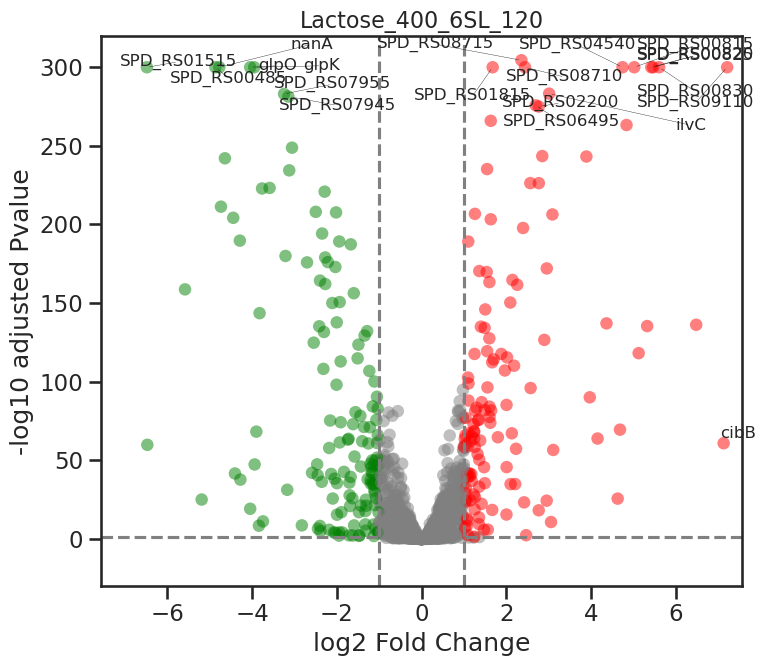

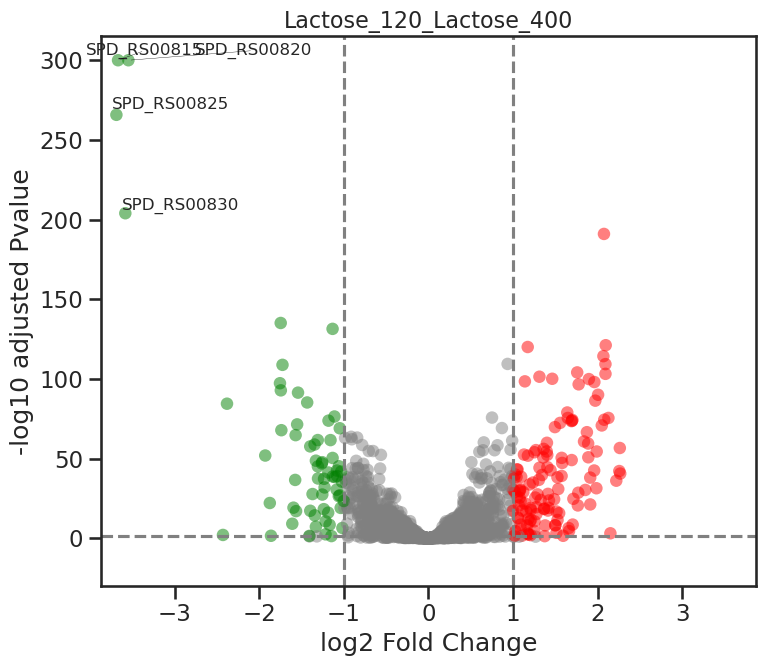

12 [0.04893613 0.13161257]
14 [ 0.993572   -0.81724687]
12 [-0.9227565   0.98488492]
14 [0.84866163 0.56122624]
15 [0.06786374 0.21282639]
12 [ 0.575756   -0.45935608]
14 [ 0.0647851 -0.2973991]
15 [-0.5403042  -0.08239129]
12 [0.87924884 0.84062377]
14 [0.53814111 0.26828849]
15 [0.38990092 0.38056617]
12 [ 0.58594367 -0.80114215]
14 [0.99289015 0.19332538]
15 [ 0.99878186 -0.99921209]
14 [ 0.35498793 -0.49360229]
15 [ 0.95823186 -0.86510545]


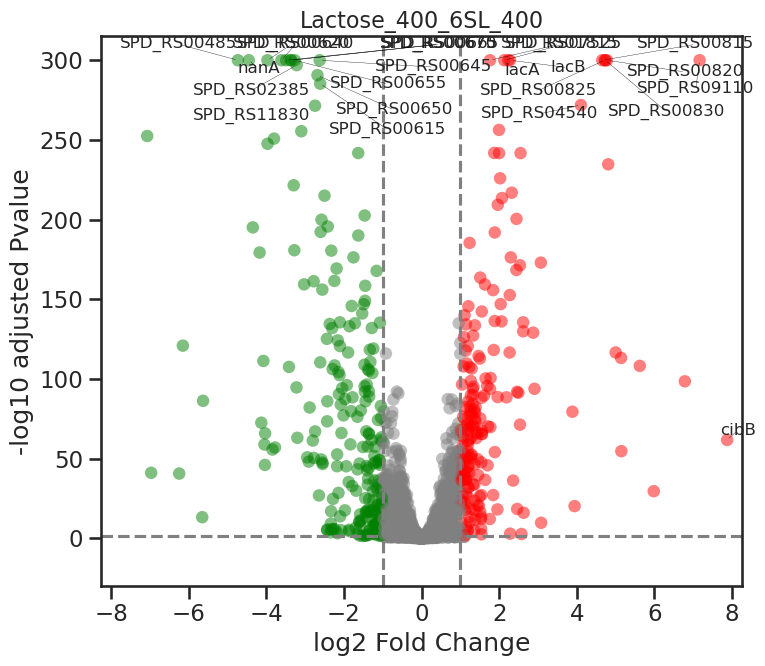

In [20]:
# Loop through DGE files
for file in out_dir.glob("DGE_*.tsv"):
    df = pd.read_csv(file, sep="\t")
    contrast_name = file.stem.replace("DGE_", "")
    volcano_plot(df, title=contrast_name, gff_df=gene_df,
                 fc_thresh=fc_thresh, p_thresh=p_thresh,
                 save_path=out_dir / f"annotated_volcano_plot_{contrast_name}.png")

In [21]:
gene_df[gene_df.locus_tag == "SPD_RS01515"]

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
588,NC_008533.2,274549,275985,+,SPD_RS01515,,,
589,NC_008533.2,274549,275985,+,SPD_RS01515,,,6-phospho-beta-glucosidase


### Heatmaps to visualize the expression of lac related genes

In [22]:
gene_df

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1,NC_008533.2,1,1362,+,SPD_RS00005,dnaA,,
2,NC_008533.2,1,1362,+,SPD_RS00005,dnaA,,chromosomal replication initiator protein DnaA
3,NC_008533.2,1521,2657,+,SPD_RS00010,dnaN,,
4,NC_008533.2,1521,2657,+,SPD_RS00010,dnaN,,DNA polymerase III subunit beta
5,NC_008533.2,2722,2916,+,SPD_RS00015,,,
...,...,...,...,...,...,...,...,...
4284,NC_008533.2,2043245,2043724,-,SPD_RS10940,rlmH,,23S rRNA (pseudouridine(1915)-N(3))-methyltran...
4285,NC_008533.2,2043907,2045088,+,SPD_RS10945,,,
4286,NC_008533.2,2043907,2045088,+,SPD_RS10945,,,S1C family serine protease
4287,NC_008533.2,2045146,2045904,+,SPD_RS10950,,,


In [23]:
mask = gene_df[['gene_id', 'gene_name', 'product']].apply(lambda x: x.str.contains('lac', case=False, na=False)).any(axis=1)
lac = gene_df[mask]

In [24]:
lac = ["SPD_RS01600", "SPD_RS01645", "SPD_RS02300", "SPD_RS02305", "SPD_RS02310", "SPD_RS05615", "SPD_RS05620", "SPD_RS05625", "SPD_RS05635", "SPD_RS05645", "SPD_RS05650", "SPD_RS08170", "SPD_RS08455", "SPD_RS08560",
      "SPD_RS09760", "SPD_RS10270"]

In [25]:
goi = ["SPD_RS00615", "SPD_RS00620", "SPD_RS00635", "SPD_RS00645", "SPD_RS00650", "SPD_RS00655", "SPD_RS00665", "SPD_RS00670", "SPD_RS00675", "SPD_RS00695", "SPD_RS10420", "SPD_RS10425", "SPD_RS10430", "SPD_RS02385"]

In [27]:
goi_df = gene_df[gene_df["locus_tag"].isin(goi)]

In [30]:
goi_df

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
241,NC_008533.2,116230,117582,+,SPD_RS00615,,,
242,NC_008533.2,116230,117582,+,SPD_RS00615,,,HlyD family efflux transporter periplasmic adaptor subunit
243,NC_008533.2,117728,118108,+,SPD_RS00620,,,
244,NC_008533.2,117728,118108,+,SPD_RS00620,,,SP_0115 family bacteriocin-like peptide
249,NC_008533.2,119688,120059,+,SPD_RS00635,,,
250,NC_008533.2,119688,120059,+,SPD_RS00635,,,SPH_0218 family bacteriocin-like peptide
255,NC_008533.2,121084,122142,+,SPD_RS00645,,,
256,NC_008533.2,121084,122142,+,SPD_RS00645,,,hypothetical protein
257,NC_008533.2,122456,123433,+,SPD_RS00650,,,
258,NC_008533.2,122456,123433,+,SPD_RS00650,,,hypothetical protein


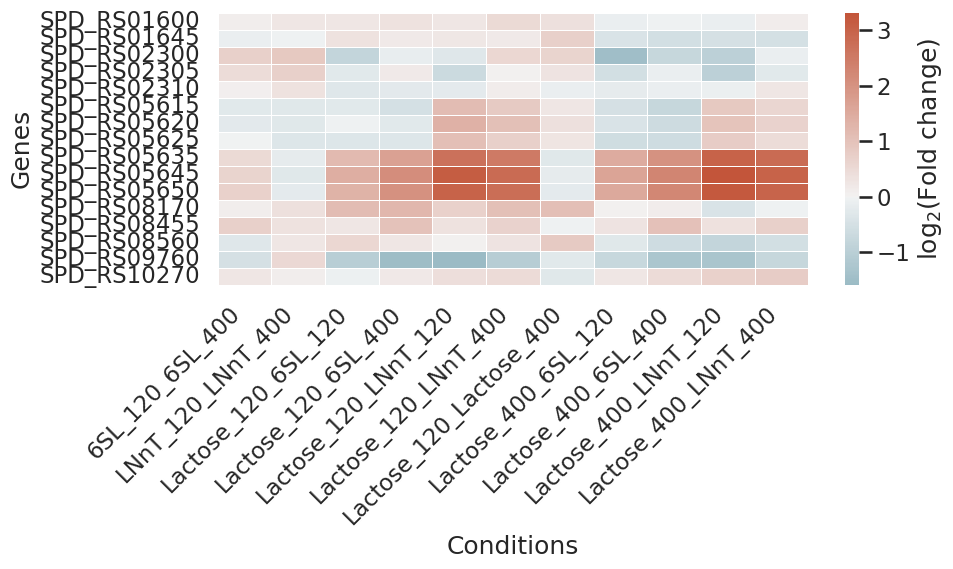

In [21]:
all_contrasts = []

for file in sorted(out_dir.glob("DGE_*.tsv")):

    df = pd.read_csv(file, sep="\t")
    df.columns = df.columns.str.strip()

    contrast_name = file.stem.replace("DGE_", "")

    deg = df.set_index("feature_id")

    # detect log2FC column automatically
    lfc_col = [c for c in deg.columns if "log2FoldChange" in c]
    if not lfc_col:
        print(f"No log2FoldChange column in {file.name}, skipping")
        continue

    lfc_col = lfc_col[0]

    lac_data = deg.loc[deg.index.intersection(lac), [lfc_col]]
    lac_data = lac_data.rename(columns={lfc_col: contrast_name})

    all_contrasts.append(lac_data)

# combine all contrasts
lac_matrix = pd.concat(all_contrasts, axis=1)

# enforce gene order
lac_matrix = lac_matrix.reindex(lac)

mask = np.isnan(lac_matrix)

sns.set_style("white")

cmap = sns.diverging_palette(220, 20, as_cmap=True)
cmap.set_bad(color="whitesmoke")

plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    lac_matrix,
    cmap=cmap,
    center=0,
    mask=mask,
    linewidths=0.5,
    cbar_kws={"label": r"log$_2$(Fold change)"}
)

plt.xlabel("Conditions")
plt.ylabel("Genes")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(out_dir / "lac_heatmap_all_conditions.svg", dpi=300)
plt.show()
plt.close()